# 05e — Model Training: Fine-Tuned DistilRoBERTa (Text-Only H1 Baseline)

| Field | Detail |
|---|---|
| **Notebook** | `05e_model_distilroberta.ipynb` |
| **Pipeline stage** | H1 — Voice Emotion Recognition - 5 of 7 (Model Training — the text baseline, not a voice candidate) |
| **Owner(s)** | *Thrithwaka Preethi Shakya* |
| **Created** | *30/08/2026* |
| **Last updated** | *30/08/2026* |
| **Upstream dependency** | `04c_asr_transcription.ipynb` (transcripts), `04a_feature_extraction_handcrafted.ipynb` (label encoding, for consistency) |
| **Downstream dependency** | `07_h1_final_evaluation.ipynb` — **not** `06_model_selection.ipynb` |
| **Runs on** | Local machine, or **Google Colab** with the project folder mounted via Google Drive (see Section 0) |
| **Research proposal reference** | Section 5.1 (*"the voice-based model's classification accuracy will be directly benchmarked against a text-only emotion classifier (DistilRoBERTa on transcribed text)"*) |

## Purpose — an important distinction from `05a`\u2013`05d`

`05a` through `05d` train four **competing voice-based candidates**; `06_model_selection.ipynb` picks the best of those four to carry forward. This notebook is different: it does not compete with the voice candidates for a spot in that comparison. It trains the **single, fixed text-only baseline** that H1 itself is actually testing against — per the proposal, H1 asks whether voice-based emotion recognition beats text-only recognition, and this model *is* the text-only side of that comparison. Its output feeds directly into `07_h1_final_evaluation.ipynb`, not into `06_model_selection.ipynb`.

### A methodologically important note this notebook surfaces for `07`

`04c_asr_transcription.ipynb` could not produce a usable transcript for every audio file — some clips (per its own diagnostic) failed ASR entirely. This model can therefore only be trained and evaluated on the subset of files where transcription succeeded, while every voice-based candidate in `05a`\u2013`05d` was trained and evaluated on the **full** test set. Since the proposal's Section 5.5 specifies a **paired** statistical test (paired t-test or Wilcoxon signed-rank) between the voice winner and this text baseline, a paired test requires predictions from *both* models on the *exact same* set of examples. **This means `07_h1_final_evaluation.ipynb` must restrict its comparison to the intersection of test files where ASR succeeded** — not the voice model's full test set — or the pairing (and therefore the statistical test) would not be valid. This notebook flags this explicitly rather than leaving it for `07` to discover as a surprise.

## Objectives

1. Load transcripts from `04c`, filtering to only successfully-transcribed rows.
2. Tokenize transcripts using the `distilroberta-base` tokenizer.
3. Fine-tune `distilroberta-base` for 6-class emotion classification, with class weights recomputed specifically for this notebook's actual (ASR-filtered) training subset.
4. Evaluate on the filtered test split using Accuracy, Precision, Recall, and F1-score.
5. Save the fine-tuned model and tokenizer in Hugging Face format, plus full run metadata.
6. Record this run in the shared experiment log, clearly distinguished from the four H1 voice candidates.
7. Leave a structured handoff note for `07_h1_final_evaluation.ipynb`, including the paired-comparison requirement above.

## 0. Environment Setup

### 0.1 Google Colab / Google Drive Setup

Same auto-detecting pattern as `05a`\u2013`05d`. Edit `PROJECT_ROOT` below if your Drive folder path differs from `MyDrive/emotion-ai-companion-research`.

**Recommended Colab runtime:** `Runtime` \u2192 `Change runtime type` \u2192 **T4 GPU** (fine-tuning DistilRoBERTa is lighter than Wav2Vec2 in `05d`, but still meaningfully faster on GPU).

In [1]:
import sys
import os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_ROOT = Path("/content/drive/MyDrive/emotion-ai-companion-research")

    if not PROJECT_ROOT.exists():
        raise FileNotFoundError(
            f"{PROJECT_ROOT} not found. Check that this path matches your Google Drive folder "
            "exactly (case-sensitive), and that the cell above finished mounting successfully."
        )

    os.chdir(PROJECT_ROOT)
    print(f"\u2705 Running on Google Colab. Project root set to: {PROJECT_ROOT}")

else:
    PROJECT_ROOT = Path.cwd()
    while not (PROJECT_ROOT / "config").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
        PROJECT_ROOT = PROJECT_ROOT.parent
    print(f"Running locally. Project root resolved to: {PROJECT_ROOT}")

sys.path.insert(0, str(PROJECT_ROOT))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Running on Google Colab. Project root set to: /content/drive/MyDrive/emotion-ai-companion-research


In [2]:
if IN_COLAB:
    print("Installing project-specific dependencies...")

    !pip install -q \
        pydantic-settings==2.4.0 \
        transformers==4.44.2 \
        tokenizers==0.19.1

    print("Installation completed.")
else:
    print("Running locally — skipping Colab-specific dependency installation.")

Installing project-specific dependencies...
Installation completed.


In [3]:
import json
import time
import logging
import subprocess
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
)

from config.settings import settings  # noqa: E402

sns.set_theme(style="whitegrid")

In [4]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("\u26a0\ufe0f  No GPU detected. If on Colab, go to Runtime \u2192 Change runtime type \u2192 "
          "T4 GPU, then re-run this notebook from the top.")

Using device: cuda


In [5]:
LOG_DIR = PROJECT_ROOT / "reports" / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH = LOG_DIR / "05e_model_distilroberta.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.FileHandler(LOG_PATH, mode="w"), logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger("model_distilroberta")
logger.info("Environment: %s", "Google Colab" if IN_COLAB else "local")

## 1. Load & Filter Transcripts

Loads `04c`'s transcript dataset and filters to `succeeded == True` only, per that notebook's own explicit recommendation. Rows with a failed/empty transcript carry no textual signal and would only teach the model a meaningless association between "no text" and whatever label happened to be attached.

In [6]:
transcripts_path = PROJECT_ROOT / "data" / "processed" / "features" / "h1_transcripts.csv"
transcripts_metadata_path = PROJECT_ROOT / "data" / "processed" / "features" / "h1_transcripts_metadata.json"
handcrafted_metadata_path = PROJECT_ROOT / "data" / "processed" / "features" / "h1_handcrafted_features_metadata.json"

for path in (transcripts_path, transcripts_metadata_path, handcrafted_metadata_path):
    if not path.exists():
        raise FileNotFoundError(f"{path} not found. Run 04c_asr_transcription.ipynb (full run, not a sample) first.")

with open(transcripts_metadata_path) as f:
    transcripts_metadata = json.load(f)
with open(handcrafted_metadata_path) as f:
    handcrafted_metadata = json.load(f)

label_to_idx = {k: int(v) for k, v in handcrafted_metadata["label_to_idx"].items()}
idx_to_label = {int(k): v for k, v in handcrafted_metadata["idx_to_label"].items()}
NUM_CLASSES = len(label_to_idx)

transcripts_df = pd.read_csv(transcripts_path)
print(f"Loaded {len(transcripts_df)} total transcript rows.")

filtered_df = transcripts_df[transcripts_df["succeeded"] == True].reset_index(drop=True)  # noqa: E712
dropped_count = len(transcripts_df) - len(filtered_df)
print(f"Filtered to {len(filtered_df)} successfully-transcribed rows ({dropped_count} dropped).")
logger.info("Filtered transcripts: %d kept, %d dropped (failed/empty ASR).", len(filtered_df), dropped_count)

Loaded 4068 total transcript rows.
Filtered to 4066 successfully-transcribed rows (2 dropped).


In [7]:
print("Split sizes after filtering (compare against 05a-05d's full-dataset split sizes — some shrinkage is expected):")
print(filtered_df["split"].value_counts())
print("\nClass distribution after filtering, by split:")
display(pd.crosstab(filtered_df["split"], filtered_df["label"]))

Split sizes after filtering (compare against 05a-05d's full-dataset split sizes — some shrinkage is expected):
split
train    3252
val       407
test      407
Name: count, dtype: int64

Class distribution after filtering, by split:


label,angry,fear,happy,neutral,sad,surprise
split,,,,,,
test,65,65,66,81,65,65
train,521,521,521,646,522,521
val,65,65,65,81,65,66


## 2. Recompute Class Weights on the Filtered Training Subset

Every other H1 notebook reuses the class weights computed once in `04a`, since they all train on the complete manifest. This notebook is the deliberate exception: because ASR failures may have dropped a different proportion of examples from different classes, the class balance of this notebook's *actual* training data can differ slightly from the full-audio class balance `04a` computed. Recomputing weights specifically on this notebook's filtered training split is the more correct choice here, not an inconsistency with the rest of the pipeline.

In [8]:
train_labels_encoded = filtered_df.loc[filtered_df["split"] == "train", "label"].map(label_to_idx).values

class_weight_values = compute_class_weight(
    class_weight="balanced", classes=np.arange(NUM_CLASSES), y=train_labels_encoded
)
class_weights_tensor = torch.tensor(class_weight_values, dtype=torch.float32).to(DEVICE)

print("Class weights (recomputed on this notebook's filtered training subset):")
for i in range(NUM_CLASSES):
    print(f"  {i} ({idx_to_label[i]}): {class_weights_tensor[i].item():.4f}")

Class weights (recomputed on this notebook's filtered training subset):
  0 (happy): 1.0403
  1 (sad): 1.0383
  2 (angry): 1.0403
  3 (fear): 1.0403
  4 (neutral): 0.8390
  5 (surprise): 1.0403


## 3. Configuration

In [9]:
MODEL_CHECKPOINT = "distilroberta-base"
MAX_SEQUENCE_LENGTH = 64   # transcripts are short spoken utterances (typically well under 20 words)
BATCH_SIZE = 16
MAX_EPOCHS = 30
LEARNING_RATE = 2e-5       # standard fine-tuning LR for RoBERTa-family models
WEIGHT_DECAY = 0.01
LR_SCHEDULER_PATIENCE = 2
LR_SCHEDULER_FACTOR = 0.5
EARLY_STOPPING_PATIENCE = 3

MODEL_DIR = PROJECT_ROOT / "models" / "h1"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DISTILROBERTA_MODEL_DIR = MODEL_DIR / "distilroberta_finetuned"
MODEL_METADATA_PATH = MODEL_DIR / "distilroberta_metadata.json"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "h1_models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_LOG_PATH = PROJECT_ROOT / "reports" / "experiment_log.csv"

logger.info(
    "Config: batch_size=%d, max_epochs=%d, lr=%.0e, max_seq_len=%d",
    BATCH_SIZE, MAX_EPOCHS, LEARNING_RATE, MAX_SEQUENCE_LENGTH,
)

## 4. Tokenization

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)


def tokenize_texts(texts: list[str]) -> dict:
    return tokenizer(
        list(texts), padding="max_length", truncation=True,
        max_length=MAX_SEQUENCE_LENGTH, return_tensors="pt",
    )


train_df = filtered_df[filtered_df["split"] == "train"]
val_df = filtered_df[filtered_df["split"] == "val"]
test_df = filtered_df[filtered_df["split"] == "test"]

train_encodings = tokenize_texts(train_df["transcript"].fillna("").tolist())
val_encodings = tokenize_texts(val_df["transcript"].fillna("").tolist())
test_encodings = tokenize_texts(test_df["transcript"].fillna("").tolist())

y_train = train_df["label"].map(label_to_idx).values
y_val = val_df["label"].map(label_to_idx).values
y_test = test_df["label"].map(label_to_idx).values

print(f"Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")
print(f"Example tokenized transcript (train[0]): \"{train_df['transcript'].iloc[0]}\"")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Train: 3252 | Val: 407 | Test: 407
Example tokenized transcript (train[0]): "Dogs are sitting by the door."


In [11]:
class TextDataset(Dataset):
    def __init__(self, encodings: dict, labels: np.ndarray):
        self.encodings = encodings
        self.labels = torch.from_numpy(labels).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


train_dataset = TextDataset(train_encodings, y_train)
val_dataset = TextDataset(val_encodings, y_val)
test_dataset = TextDataset(test_encodings, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(RANDOM_SEED))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 5. Load Pretrained Model

Full fine-tuning (no layer freezing) — the standard, well-established recipe for adapting a DistilRoBERTa-scale model to a downstream text classification task, unlike `05d`'s Wav2Vec2 approach, which froze its feature encoder specifically because that component was pretrained on 960 hours of raw audio and is disproportionately expensive to relearn correctly from a small dataset. Full fine-tuning of a compact, already-distilled language model on 6-way text classification is comparatively low-risk by comparison.

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=NUM_CLASSES
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params / total_params:.1%} of total — full fine-tuning)")
logger.info("Loaded %s. Trainable params: %d / %d", MODEL_CHECKPOINT, trainable_params, total_params)

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters:     82,123,014
Trainable parameters: 82,123,014 (100.0% of total — full fine-tuning)


## 6. Training Loop

Same structural discipline as `05a`\u2013`05d`: class-weighted loss computed externally, `ReduceLROnPlateau`, early stopping on validation loss, best checkpoint saved by validation loss.

In [13]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE
)


def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * input_ids.size(0)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy

In [14]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float("inf")
epochs_without_improvement = 0
best_epoch = 0

training_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc = run_epoch(val_loader, model, criterion, optimizer=None)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    logger.info(
        "Epoch %3d | train_loss=%.4f train_acc=%.4f | val_loss=%.4f val_acc=%.4f | lr=%.2e",
        epoch, train_loss, train_acc, val_loss, val_acc, current_lr,
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0
        model.save_pretrained(DISTILROBERTA_MODEL_DIR)
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        logger.info("Early stopping triggered at epoch %d (best epoch: %d).", epoch, best_epoch)
        print(f"Early stopping at epoch {epoch} (best epoch: {best_epoch}, best val_loss: {best_val_loss:.4f})")
        break

training_duration_seconds = time.time() - training_start
print(f"\nTraining complete in {training_duration_seconds:.1f}s. Best epoch: {best_epoch} (val_loss={best_val_loss:.4f}).")

tokenizer.save_pretrained(DISTILROBERTA_MODEL_DIR)
print(f"Tokenizer saved alongside model at: {DISTILROBERTA_MODEL_DIR}")

Early stopping at epoch 8 (best epoch: 5, best val_loss: 1.5753)

Training complete in 181.7s. Best epoch: 5 (val_loss=1.5753).
Tokenizer saved alongside model at: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/distilroberta_finetuned


## 7. Training Curves

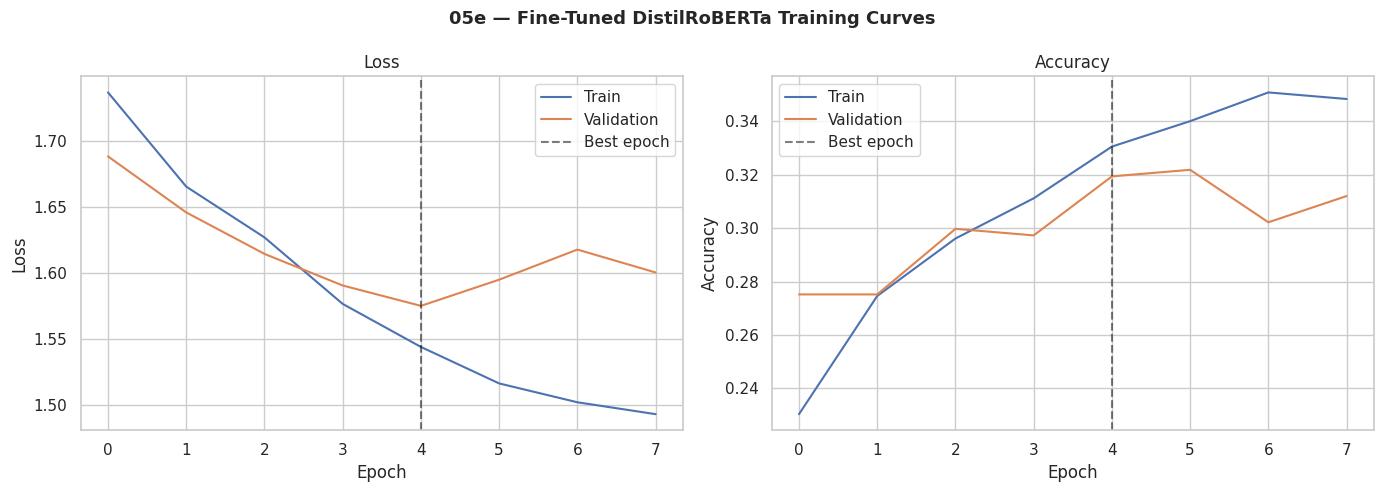

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].axvline(best_epoch - 1, color="black", linestyle="--", alpha=0.5, label="Best epoch")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Validation")
axes[1].axvline(best_epoch - 1, color="black", linestyle="--", alpha=0.5, label="Best epoch")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

fig.suptitle("05e — Fine-Tuned DistilRoBERTa Training Curves", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05e_training_curves.png")
plt.show()

## 8. Test Set Evaluation

Reloaded via `from_pretrained` — the same loading path `07_h1_final_evaluation.ipynb` will use.

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(DISTILROBERTA_MODEL_DIR).to(DEVICE)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch["labels"].numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)

print(f"Test Accuracy:            {test_accuracy:.4f}")
print(f"Test Precision (macro):   {precision_macro:.4f}")
print(f"Test Recall (macro):      {recall_macro:.4f}")
print(f"Test F1 (macro):          {f1_macro:.4f}")
print(f"Test F1 (weighted):       {f1_weighted:.4f}")
print("\nPer-class report:\n")
print(classification_report(
    all_labels, all_preds, target_names=[idx_to_label[i] for i in range(NUM_CLASSES)], zero_division=0
))

Test Accuracy:            0.3120
Test Precision (macro):   0.3824
Test Recall (macro):      0.3051
Test F1 (macro):          0.2969
Test F1 (weighted):       0.2998

Per-class report:

              precision    recall  f1-score   support

       happy       0.23      0.52      0.31        66
         sad       0.36      0.08      0.13        65
       angry       0.29      0.22      0.25        65
        fear       0.40      0.29      0.34        65
     neutral       0.31      0.47      0.37        81
    surprise       0.71      0.26      0.38        65

    accuracy                           0.31       407
   macro avg       0.38      0.31      0.30       407
weighted avg       0.38      0.31      0.30       407



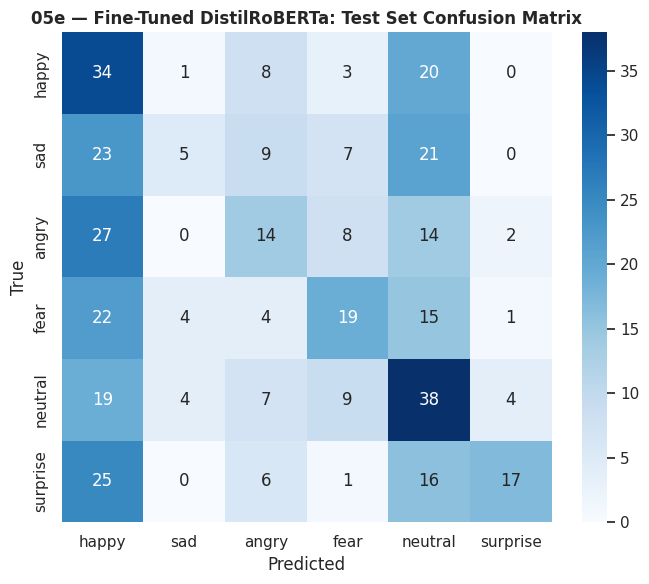

In [17]:
cm = confusion_matrix(all_labels, all_preds)
labels_ordered = [idx_to_label[i] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_ordered, yticklabels=labels_ordered, ax=ax)
ax.set_title("05e — Fine-Tuned DistilRoBERTa: Test Set Confusion Matrix", fontsize=12, weight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05e_confusion_matrix.png")
plt.show()

## 9. Save the Test-Set File List — Required for `07`'s Paired Comparison

Saves exactly which `original_path` values made up this notebook's test set. `07_h1_final_evaluation.ipynb` needs this list to restrict the voice model's predictions to the same files before running the paired significance test — without it, there is no reliable way to guarantee the two models' predictions are being compared example-for-example on identical data.

In [18]:
test_file_list_path = MODEL_DIR / "distilroberta_test_files.csv"
test_df[["original_path", "label", "transcript"]].assign(
    distilroberta_prediction=[idx_to_label[p] for p in all_preds]
).to_csv(test_file_list_path, index=False)

logger.info("Saved test file list (for 07's paired comparison) to %s", test_file_list_path)
print(f"Saved: {test_file_list_path} ({len(test_df)} files)")

Saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/distilroberta_test_files.csv (407 files)


## 10. Save Model Metadata

In [19]:
def get_git_commit_hash() -> str:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, stderr=subprocess.DEVNULL
        ).decode().strip()
    except Exception:
        return "unknown"


model_metadata = {
    "model_name": "distilroberta_text_baseline",
    "role": "H1 TEXT-ONLY BASELINE — not a competing voice candidate; used directly in 07_h1_final_evaluation.ipynb",
    "base_checkpoint": MODEL_CHECKPOINT,
    "num_classes": NUM_CLASSES,
    "label_to_idx": label_to_idx,
    "asr_filtering": {
        "total_transcript_rows": int(len(transcripts_df)),
        "rows_kept_after_filtering": int(len(filtered_df)),
        "rows_dropped_failed_asr": int(dropped_count),
    },
    "hyperparameters": {
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "max_sequence_length": MAX_SEQUENCE_LENGTH,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "lr_scheduler_patience": LR_SCHEDULER_PATIENCE,
        "full_fine_tuning": True,
    },
    "training": {
        "best_epoch": best_epoch,
        "epochs_run": len(history["train_loss"]),
        "best_val_loss": float(best_val_loss),
        "training_duration_seconds": round(training_duration_seconds, 1),
        "device": str(DEVICE),
        "environment": "Google Colab" if IN_COLAB else "local",
        "total_parameters": int(total_params),
    },
    "test_metrics": {
        "accuracy": float(test_accuracy),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
    },
    "git_commit": get_git_commit_hash(),
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "model_dir": str(DISTILROBERTA_MODEL_DIR.relative_to(PROJECT_ROOT)),
    "test_file_list_path": str(test_file_list_path.relative_to(PROJECT_ROOT)),
    "important_note_for_07": (
        "07_h1_final_evaluation.ipynb MUST restrict its paired comparison to the original_path values "
        "listed in distilroberta_test_files.csv — the voice model's full test set will contain files "
        "this text baseline could not be evaluated on, due to ASR failures."
    ),
}

with open(MODEL_METADATA_PATH, "w") as f:
    json.dump(model_metadata, f, indent=2)

logger.info("Saved model metadata to %s", MODEL_METADATA_PATH)
print(f"Saved: {DISTILROBERTA_MODEL_DIR}/ (Hugging Face format: model + tokenizer)")
print(f"Saved: {MODEL_METADATA_PATH}")

Saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/distilroberta_finetuned/ (Hugging Face format: model + tokenizer)
Saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/distilroberta_metadata.json


## 11. Record in Shared Experiment Log

Logged with a clear `role` note distinguishing it from the four competing voice candidates — `06_model_selection.ipynb` should exclude this row from its voice-model comparison; it exists in this shared log purely for a complete, auditable record of every model trained in this project.

In [20]:
experiment_row = {
    "notebook": "05e_model_distilroberta",
    "model_name": "distilroberta_text_baseline",
    "role": "H1 text-only baseline (not a voice candidate)",
    "timestamp_utc": model_metadata["trained_at_utc"],
    "git_commit": model_metadata["git_commit"],
    "environment": model_metadata["training"]["environment"],
    "test_accuracy": test_accuracy,
    "test_precision_macro": precision_macro,
    "test_recall_macro": recall_macro,
    "test_f1_macro": f1_macro,
    "test_f1_weighted": f1_weighted,
    "best_epoch": best_epoch,
    "epochs_run": len(history["train_loss"]),
    "total_parameters": total_params,
    "training_duration_seconds": round(training_duration_seconds, 1),
    "model_metadata_path": str(MODEL_METADATA_PATH.relative_to(PROJECT_ROOT)),
}

experiment_log_df = (
    pd.read_csv(EXPERIMENT_LOG_PATH) if EXPERIMENT_LOG_PATH.exists() else pd.DataFrame()
)
experiment_log_df = pd.concat([experiment_log_df, pd.DataFrame([experiment_row])], ignore_index=True)
experiment_log_df.to_csv(EXPERIMENT_LOG_PATH, index=False)

logger.info("Appended results to shared experiment log: %s", EXPERIMENT_LOG_PATH)
print(f"Appended to: {EXPERIMENT_LOG_PATH}")

Appended to: /content/drive/MyDrive/emotion-ai-companion-research/reports/experiment_log.csv


## 12. Final Sanity Check — Reload and Verify

In [21]:
reload_model = AutoModelForSequenceClassification.from_pretrained(DISTILROBERTA_MODEL_DIR).to(DEVICE)
reload_tokenizer = AutoTokenizer.from_pretrained(DISTILROBERTA_MODEL_DIR)
reload_model.eval()

sample_batch = next(iter(test_loader))
with torch.no_grad():
    reload_logits = reload_model(
        input_ids=sample_batch["input_ids"].to(DEVICE),
        attention_mask=sample_batch["attention_mask"].to(DEVICE),
    ).logits
    reload_preds = reload_logits.argmax(dim=1).cpu()

assert reload_logits.shape == (sample_batch["input_ids"].shape[0], NUM_CLASSES), "Unexpected output shape!"
print("\u2705 Reloaded model and tokenizer produce correctly-shaped output.")
print(f"Sample predictions: {[idx_to_label[p.item()] for p in reload_preds[:5]]}")
print(f"Sample true labels: {[idx_to_label[l.item()] for l in sample_batch['labels'][:5]]}")

✅ Reloaded model and tokenizer produce correctly-shaped output.
Sample predictions: ['angry', 'neutral', 'happy', 'neutral', 'angry']
Sample true labels: ['angry', 'sad', 'surprise', 'neutral', 'surprise']


---

## Summary Note — Handoff

### What was done in this notebook

1. Loaded `04c`'s transcripts and filtered to successfully-transcribed rows only.
2. Recomputed class weights specifically on this notebook's filtered training subset (a deliberate, documented exception to the "always reuse 04a's weights" pattern used by `05a`\u2013`05d`).
3. Fully fine-tuned `distilroberta-base` (no layer freezing) for 6-class emotion classification.
4. Evaluated on the filtered test split: Accuracy, Precision, Recall, F1, classification report, confusion matrix.
5. Saved the exact list of test files used here — required for `07`'s paired comparison.
6. Saved the fine-tuned model and tokenizer in Hugging Face format, plus full metadata.
7. Recorded this run in the shared experiment log, clearly flagged as the H1 text baseline, not a voice candidate.

### Outputs produced by this notebook (and where to find them)

| Output | Location | Used by |
|---|---|---|
| Fine-tuned model + tokenizer (Hugging Face format) | `models/h1/distilroberta_finetuned/` | `07_h1_final_evaluation.ipynb`; `src/emotion/text_emotion.py` if promoted to deployment |
| **Test file list (critical for `07`)** | `models/h1/distilroberta_test_files.csv` | `07_h1_final_evaluation.ipynb` — restricts the voice winner's predictions to this exact file set before the paired test |
| Model metadata | `models/h1/distilroberta_metadata.json` | `07_h1_final_evaluation.ipynb`; thesis results section |
| Training curves / confusion matrix figures | `reports/figures/h1_models/05e_*.png` | Thesis results/appendix |
| Shared experiment log (one row, flagged `role`) | `reports/experiment_log.csv` | Full project audit trail — excluded from `06`'s voice-candidate comparison |
| Run log | `reports/logs/05e_model_distilroberta.log` | Debugging |

### An important path distinction for this model

`config/settings.py` defines `text_emotion_model_path = "models/text_emotion/distilroberta_finetuned"` — the live app's expected path. This notebook saves to `models/h1/distilroberta_finetuned/` instead, since H1 has not yet concluded. If the thesis's final H1 result supports deploying this text baseline (or a similar model) in the live app, copy it to the deployment path as an explicit, separate step.

### What needs to be done next

With all five H1 model-training notebooks complete (`05a`\u2013`05d` voice candidates, `05e` text baseline), proceed to:

1. **`06_model_selection.ipynb`** — compares only the four voice candidates (`05a`\u2013`05d`) via `reports/experiment_log.csv`, selecting the best one.
2. **`07_h1_final_evaluation.ipynb`** — the actual H1 hypothesis test. **Must**:
   - Load `models/h1/distilroberta_test_files.csv` and restrict the voice winner's test predictions to only those `original_path` values.
   - Run the winning voice model and this notebook's DistilRoBERTa on that identical, paired set of files.
   - Apply the paired t-test or Wilcoxon signed-rank test specified in the proposal's Section 5.5 to the resulting per-example correct/incorrect (or accuracy) pairs.

**Before running `07`, confirm:**
- `models/h1/distilroberta_test_files.csv` exists and contains the expected number of rows.
- `distilroberta_metadata.json`'s `important_note_for_07` field has actually been read and understood by whoever implements `07`.
- Section 12's reload sanity check printed \u2705.

### Resources needed for the next step

| Resource | Needed for | Notes |
|---|---|---|
| `models/h1/distilroberta_finetuned/` | The text-only side of the H1 comparison | Hugging Face format — load via `from_pretrained` |
| `models/h1/distilroberta_test_files.csv` | **Required** for a statistically valid paired test in `07` | Do not skip this — comparing on mismatched test sets invalidates the paired significance test |
| The H1 voice winner from `06_model_selection.ipynb` | The voice side of the H1 comparison | Whichever of `05a`\u2013`05d` scores highest |

### Known issues / things to watch for

- *None*

### Run metadata

- **Run by:** *Thrithwaka Preethi Shakya*
- **Date:** *30/08/2026*
- **Environment:** *Colab*
- **Rows dropped due to failed ASR:** *2*
- **Test accuracy / F1 (macro):** *0.2969*